# Projeção para o Marco Legal do Saneamento 2033

metas da Lei 14.026/2020 (Marco Legal do Saneamento):
- **Água:** 99% de cobertura até 2033
- **Esgoto:** 90% de coleta até 2033


## 1. Carregamento dos dados


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RENAME_COLS = {
    "Município": "nome_municipio",
    "Sigla UF": "sigla_uf",
    "Atendimento da população total com rede de abastecimento de água": "indice_atendimento_total_agua",
    "Atendimento da população urbana com rede coletora de esgoto": "indice_coleta_esgoto",
}

path = "../data/processed/snis_sinisa_merge_ibge_populacao.csv"
df = pd.read_csv(path, encoding="utf-8")
df.rename(columns=RENAME_COLS, inplace=True)
df["ano"] = df["ano"].astype(int)
df["id_municipio"] = df["id_municipio"].astype(str).str.strip()

ultimo_ano = df["ano"].max()
META_AGUA = 99.0
META_ESGOTO = 90.0
ANO_META = 2033

print(f"Período disponível: {df['ano'].min()} a {ultimo_ano}")
print(f"Municípios: {df['id_municipio'].nunique()}")
print(f"Linhas: {len(df)}")


Período disponível: 2014 a 2024
Municípios: 92
Linhas: 980


## 2. projeção linear

reta de regressão (grau 1) aos dados históricos:

$$y = a \cdot x + b$$

Onde:
- $y$ = valor do indicador (%)
- $x$ = ano
- $a$ = taxa de variação anual (pp/ano)
- $b$ = ponto de interseção

A projeção para 2033 é simplesmente avaliar a reta em $x = 2033$.


## 3. Exemplo com um município


In [73]:
municipio_exemplo = "Piraí"
indicador = "indice_atendimento_total_agua"
meta = META_AGUA

g = df[(df["nome_municipio"] == municipio_exemplo) &
       df["ano"].between(2014, ultimo_ano)][["ano", indicador]].dropna()

print(f"Município: {municipio_exemplo}")
print(f"Dados disponíveis: {len(g)} anos ({g['ano'].min()}-{g['ano'].max()})\n")
print(g.to_string(index=False))


Município: Piraí
Dados disponíveis: 11 anos (2014-2024)

 ano  indice_atendimento_total_agua
2024                          97.88
2023                          80.16
2022                          89.94
2021                          79.18
2020                          77.70
2019                          79.18
2018                          77.47
2017                          91.40
2016                          95.86
2015                          99.50
2014                          99.17


In [74]:
coef = np.polyfit(g["ano"].values.astype(float), g[indicador].values, 1)
taxa = coef[0]
intercepto = coef[1]

print(f"Taxa de variação: {taxa:.3f} pp/ano")
print(f"ponto de interseção: {intercepto:.2f}")
print(f"Equação da reta: y = {taxa:.3f} * ano + ({intercepto:.2f})")

# Valor atual estimado pela reta
atual = float(np.polyval(coef, ultimo_ano))
print(f"\nValor estimado atual ({ultimo_ano}): {atual:.1f}%")

# Projeção para 2033
proj = float(np.polyval(coef, ANO_META))
proj = min(max(proj, 0), 100)
print(f"Projeção para {ANO_META}: {proj:.1f}%")
print(f"Meta: {meta}%")
print(f"\nDiferença projeção vs meta: {proj - meta:.1f} pp")


Taxa de variação: -1.143 pp/ano
ponto de interseção: 2396.58
Equação da reta: y = -1.143 * ano + (2396.58)

Valor estimado atual (2024): 82.2%
Projeção para 2033: 71.9%
Meta: 99.0%

Diferença projeção vs meta: -27.1 pp


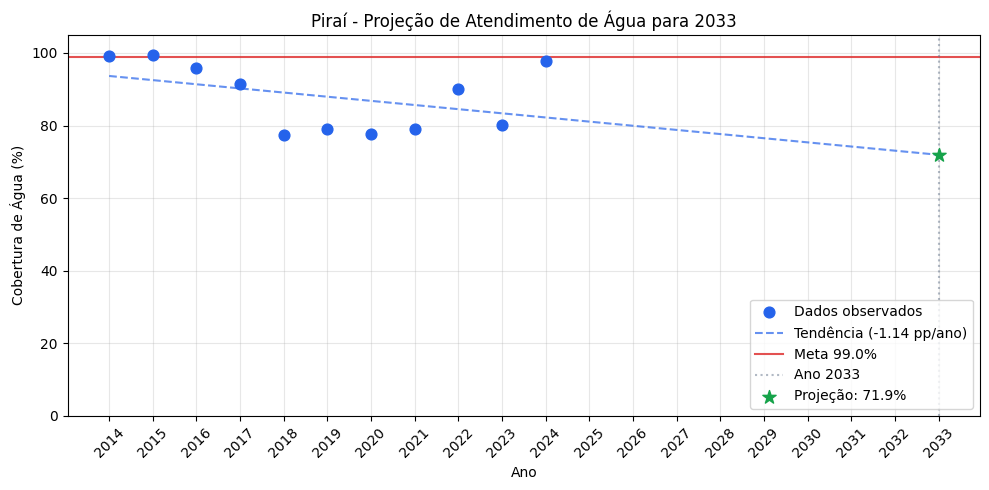

In [75]:
# Visualização do exemplo
fig, ax = plt.subplots(figsize=(10, 5))

# Dados históricos
ax.scatter(g["ano"], g[indicador], color="#2563eb", s=60, zorder=5, label="Dados observados")

# Reta de regressão + projeção
anos_range = np.arange(2014, 2034)
valores_reta = np.polyval(coef, anos_range)
ax.plot(anos_range, valores_reta, "--", color="#2563eb", alpha=0.7, label=f"Tendência ({taxa:.2f} pp/ano)")

# Meta e ano-alvo
ax.axhline(y=meta, color="#dc2626", linestyle="-", alpha=0.8, label=f"Meta {meta}%")
ax.axvline(x=ANO_META, color="#64748b", linestyle=":", alpha=0.5, label=f"Ano {ANO_META}")

# Ponto da projeção
ax.scatter([ANO_META], [proj], color="#16a34a", s=100, marker="*", zorder=6, label=f"Projeção: {proj:.1f}%")

ax.set_xlabel("Ano")
ax.set_ylabel(f"Cobertura de Água (%)")
ax.set_title(f"{municipio_exemplo} - Projeção de Atendimento de Água para 2033")
ax.legend(loc="lower right")
ax.set_ylim(0, 105)
ax.set_xticks(range(2014, 2034))
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 4. Classificação dos municípios

**Já atingiu**: Valor atual >= meta

**No prazo**: Taxa > 0 e projeção atinge meta antes de 2033

**Não atingirá**: Taxa > 0 mas projeção não atinge meta até 2033

**Em retrocesso**: Taxa <= 0 (indicador em queda)


In [76]:
def projetar_municipio(g, indicador, meta, ano_meta=2033):
    """Calcula projeção linear para um município."""
    if len(g) < 3:
        return None

    coef = np.polyfit(g["ano"].values.astype(float), g[indicador].values, 1)
    taxa = coef[0]
    atual = float(np.polyval(coef, ultimo_ano))
    proj = float(np.polyval(coef, ano_meta))
    proj = min(max(proj, 0), 100)

    if atual >= meta:
        status = "Já atingiu"
    elif taxa <= 0:
        status = "Em retrocesso"
    else:
        try:
            ano_p = int(np.ceil((meta - coef[1]) / coef[0]))
        except (ZeroDivisionError, OverflowError):
            ano_p = 9999
        status = "No prazo" if ano_p <= ano_meta else "Não atingirá"

    return {
        "taxa_pp_ano": round(taxa, 3),
        "atual_pct": round(atual, 1),
        "projecao_2033_pct": round(proj, 1),
        "status": status,
    }


## 5. Resultados - Água (meta 99%)


In [77]:
indicador = "indice_atendimento_total_agua"
meta = META_AGUA

df_h = df[df["ano"].between(2014, ultimo_ano)][["ano", "id_municipio", "nome_municipio", indicador]].dropna()

resultados = []
for mid, g in df_h.groupby("id_municipio"):
    r = projetar_municipio(g, indicador, meta)
    if r:
        r["municipio"] = g["nome_municipio"].iloc[0]
        resultados.append(r)

df_agua = pd.DataFrame(resultados)
print(f"Municípios analisados (Água): {len(df_agua)}")
print(f"\nDistribuição por status:")
print(df_agua["status"].value_counts().to_string())


Municípios analisados (Água): 92

Distribuição por status:
status
Em retrocesso    46
Não atingirá     24
No prazo         12
Já atingiu       10


In [78]:
for status in ["Já atingiu", "No prazo", "Não atingirá", "Em retrocesso"]:
    sub = df_agua[df_agua["status"] == status].sort_values("projecao_2033_pct")
    if sub.empty:
        continue
    print(f"\n{'='*60}")
    print(f"{status.upper()} ({len(sub)} municípios)")
    print(f"{'='*60}")
    print(sub[["municipio", "atual_pct", "taxa_pp_ano", "projecao_2033_pct"]].to_string(index=False))



JÁ ATINGIU (10 municípios)
            municipio  atual_pct  taxa_pp_ano  projecao_2033_pct
                Areal       99.7       -0.039               99.3
        Volta Redonda       99.7       -0.037               99.4
Campos dos Goytacazes      100.3        0.913              100.0
            Cabo Frio      102.7        3.267              100.0
             Mesquita      100.3        0.309              100.0
            Nilópolis       99.7        0.047              100.0
              Niterói      100.0       -0.000              100.0
  Conceição de Macabu      100.7        4.735              100.0
  São Pedro da Aldeia       99.2        0.932              100.0
            Saquarema      100.9        0.919              100.0

NO PRAZO (12 municípios)
                  municipio  atual_pct  taxa_pp_ano  projecao_2033_pct
            Arraial do Cabo       98.1        0.118               99.2
                   Araruama       98.8        0.519              100.0
               Bel

## 6. Resultados - Esgoto (meta 90%)


In [79]:
indicador = "indice_coleta_esgoto"
meta = META_ESGOTO

df_h = df[df["ano"].between(2014, ultimo_ano)][["ano", "id_municipio", "nome_municipio", indicador]].dropna()

resultados = []
for mid, g in df_h.groupby("id_municipio"):
    r = projetar_municipio(g, indicador, meta)
    if r:
        r["municipio"] = g["nome_municipio"].iloc[0]
        resultados.append(r)

df_esgoto = pd.DataFrame(resultados)
print(f"Municípios analisados (Esgoto): {len(df_esgoto)}")
print(f"\nDistribuição por status:")
print(df_esgoto["status"].value_counts().to_string())


Municípios analisados (Esgoto): 84

Distribuição por status:
status
Em retrocesso    43
Já atingiu       22
Não atingirá     12
No prazo          7


In [80]:
for status in ["Já atingiu", "No prazo", "Não atingirá", "Em retrocesso"]:
    sub = df_esgoto[df_esgoto["status"] == status].sort_values("projecao_2033_pct")
    if sub.empty:
        continue
    print(f"\n{'='*60}")
    print(f"{status.upper()} ({len(sub)} municípios)")
    print(f"{'='*60}")
    print(sub[["municipio", "atual_pct", "taxa_pp_ano", "projecao_2033_pct"]].to_string(index=False))



JÁ ATINGIU (22 municípios)
                  municipio  atual_pct  taxa_pp_ano  projecao_2033_pct
                 Petrópolis       91.0       -1.244               79.8
                  Cabo Frio       92.4       -0.814               85.1
              Nova Friburgo       92.0       -0.438               88.1
            Arraial do Cabo       94.9       -0.413               91.2
              Iguaba Grande       95.3       -0.123               94.2
                     Italva       94.7       -0.026               94.5
                    Niterói       98.1       -0.131               96.9
                    Resende       98.3        0.084               99.1
             Laje do Muriaé      106.0        9.255              100.0
                  Itaperuna       99.9        9.476              100.0
  Comendador Levy Gasparian      103.8        2.522              100.0
                 Natividade       94.4        5.855              100.0
                   Miracema      100.2        0.0